In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from utils import plot2Dimage, RelL2Loss
import time

In [28]:
class ConvergentBornSeries(nn.Module):
    def __init__(self,
                 lamb=1,
                 sos=None,
                 dx=None,
                 src_loc=[30,60],
                 boundary_width=[8,8],
                 boundary_strength=1,
                 boundary_type='PML3',
                 dtype=torch.float64
                 ):
        super().__init__()
        torch.set_default_dtype(dtype)
        # PDE params
        self.lamb = lamb # wavelength, the units depend on the length units of the spacial field
        self.omega0 = 2*torch.pi/self.lamb
        self.PPW = 4 # points per wavelength
        if dx is None:# default dx = 1/4 wavelength
            self.pixel_size = self.lamb / self.PPW 
        else:
            self.pixel_size = dx
        if sos is None:
            # It is not difficult to understand from the Helmholtz equation that: 
            # the wavelength is determined by the velocity field (sos) and the coefficient lambda(lamb).
            # But our pixel_size is only adjusted according to the value of lambda
            # Therefore, when we adjust lambda, the appearance of the resulting wavefield remains unchanged. 
            # This is because the pixel_size becomes larger.Actually, the physical space got bigger.
            # But when we adjust the velocity field, the resulting wave field will change, 
            # because the velocity field does not affect our grid spacing
            num_waves = 32# number of waves
            self.N = num_waves*torch.tensor([self.PPW, self.PPW],dtype=int)
            self.sos = torch.ones(self.N[0],self.N[1])+\
                       torch.sin(torch.linspace(0,8,self.N[0]).view(-1,1))*torch.ones(1,self.N[1])*0.5
        else:
            self.sos = sos
            self.N = torch.tensor(sos.size()).to(int)

        self.inv_sos2 = 1/self.sos**2
        inv_sos2_center = (torch.max(self.inv_sos2) + torch.min(self.inv_sos2))/2
        
        # src
        # src_loc = torch.tensor(src_loc,dtype=int).view(2,-1) # single point source
        # bug of torch.sparse_coo_tensor cuda different with cpu
        # self.src = torch.sparse_coo_tensor(indices=src_loc,values=1.,size=(self.sos.size(0),self.sos.size(1))).to('cpu')
        
        self.src = torch.zeros_like(self.sos)
        self.src[src_loc[0],src_loc[1]] = 1.
        self.src = nn.Parameter(self.src,requires_grad=False)

        # boundary
        self.boundary_widths = torch.tensor(boundary_width,dtype=int)
        self.boundary_strength = boundary_strength
        self.boundary_type = boundary_type
        self.set_grid()
        self.set_boundary()

        # CBS params
        self.k0 = torch.sqrt(inv_sos2_center)*self.omega0
        self.epsilon = torch.max(torch.abs(self.inv_sos2*self.omega0**2 - self.k0**2))
        # scatter potential
        self.V = nn.Parameter(self.inv_sos2*self.omega0**2 - self.k0**2 - 1.0j*self.epsilon, requires_grad=False)
        # g0_tilde
        self.g0 = nn.Parameter(1/(self.px_range**2+self.py_range**2-self.k0**2 - 1.0j*self.epsilon), requires_grad=False)

        # gamma
        self.gamma = nn.Parameter(1.j/self.epsilon*self.V, requires_grad=False)
    # def solve(self,max_iters=2000,tol=1e-16):
    #     self.u = torch.zeros(self.new_N[0],self.new_N[1]).to(self.V.device)
    #     for i in range(max_iters):
            
    #         # self.src_loc_ = self.
    #         tmp1 = self.V*self.u
    #         # point source
    #         tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

    #         tmp2 = (1.j/self.epsilon*self.V) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
    #         self.u = self.u - tmp2

    def forward(self,max_iters=5, requries_grad=False, tol=1e-10, dispstep=500):
        self.u = torch.zeros(self.new_N[0],self.new_N[1]).to(self.V.device)
        if requries_grad:
            for i in range(max_iters):
                
                tmp1 = self.V*self.u
                # point source
                tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

                tmp2 = (self.gamma) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                self.u = self.u - tmp2
        else:
            with torch.no_grad():
                t_s = time.perf_counter()
                for i in range(max_iters):
                    
                    tmp1 = self.V*self.u
                    # point source
                    tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

                    tmp2 = (self.gamma) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
                    self.u = self.u - tmp2
                    err = torch.linalg.norm(tmp2)
                    if err < tol:
                        t_e = time.perf_counter()
                        print(f'step: {i:4d}, meet tol: {err:.4e}, solve time: {t_e-t_s:.2f}s')
                        break
                    if i % dispstep == 0:
                        print(f"step: {i:4d}, diff norm: {err:.4e}")
                t_e = time.perf_counter()

        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]]

    def set_grid(self):
        # set grid in spacial and spectral domains

        self.new_N = (2**(torch.ceil(torch.log2(self.N + self.boundary_widths)))).to(int) # To improve FFT efficiency

        self.padding_size = self.new_N - self.N - self.boundary_widths # zero padding, placed at right and bottom sides only (non-centric)
        # spacial coordinates
        # debug: why N[1] is x
        self.x_range = (torch.arange(self.new_N[0])*self.pixel_size).view(-1,1)
        self.y_range = (torch.arange(self.new_N[1])*self.pixel_size)
        # spectral coordinates
        self.px_range = 2*torch.pi*torch.fft.fftfreq(self.new_N[0],d=self.pixel_size).view(-1,1)
        self.py_range = (2*torch.pi*torch.fft.fftfreq(self.new_N[1],d=self.pixel_size))

    def set_boundary(self): 
        # add padding
        self.roi_size = torch.tensor(self.sos.size())
        self.Bl = torch.ceil((self.new_N - self.roi_size)/2).to(int)
        self.Br = torch.floor((self.new_N - self.roi_size)/2).to(int)
        self.roi = [[self.Bl[0],self.Bl[0]+self.roi_size[0]],
                    [self.Bl[1],self.Bl[1]+self.roi_size[1]]]

        self.inv_sos2 = F.pad(self.inv_sos2.unsqueeze(0), 
                              (self.Bl[1], self.Br[1], self.Bl[0], self.Br[0]), 
                              mode='replicate').squeeze()
        # add boundary
        Bmax = torch.max(self.Br)
        # debug: why divide self.pixel_size ?
        k0 = torch.sqrt(torch.mean(self.inv_sos2))*2*torch.pi/(self.lamb/self.pixel_size)# k0 in 1/pixels
        # maximum value of the boundary (see Mathematica file = c(c-2ik0) = boundary_strength)
        # ||^2 = |c|^2 (|c|^2 + 4k0^2)   [assuming c=real, better possible when c complex?]
        # when |c| << |2k0| we can approximage: boundary_strength = 2 k0 c
        c = self.boundary_strength*k0**2 / (2*k0)
        x = torch.cat((torch.arange(self.Bl[0], 0, -1), torch.zeros(self.roi_size[0]), torch.arange(1, self.Br[0] + 1))).view(-1,1)
        y = torch.cat((torch.arange(self.Bl[1], 0, -1), torch.zeros(self.roi_size[1]), torch.arange(1, self.Br[1] + 1)))
        dist = torch.sqrt(x**2 + y**2)
        # the shape of the boundary is determined by f_boundary_curve, a function
        # that takes a position (in pixels, 0=start of boundary) and returns
        # Delta inv_sos2 for the boundary. 
        f_boundary_curve, leakage = self.compute_leakage_and_boundary_curve(boundary_type=self.boundary_type,
                                                                            r=dist,
                                                                            Bmax=Bmax,
                                                                            c=c,
                                                                            k0=k0)
        self.inv_sos2 = self.inv_sos2 + f_boundary_curve.to(self.inv_sos2.device)
        self.leakage = leakage

    def compute_leakage_and_boundary_curve(self,boundary_type, r, Bmax, c, k0):
        # cannot understand this
        if boundary_type == 'PML5':  # 5th order smooth
            f_boundary_curve = 1 / k0**2 * (c**7 * r**5 * (6.0 + (2.0j * k0 - c) * r)) / \
                (720 + 720 * c * r + 360 * c**2 * r**2 + 120 * c**3 * r**3 + 30 * c**4 * r**4 + 6 * c**5 * r**5 + c**6 * r**6)
            leakage = torch.exp(-c * Bmax) * (720 + 720 * c * Bmax + 360 * c**2 * Bmax**2 + 
                                            120 * c**3 * Bmax**3 + 30 * c**4 * Bmax**4 + 
                                            6 * c**5 * Bmax**5 + c**6 * Bmax**6) / 24
        elif boundary_type == 'PML4':  # 4th order smooth
            f_boundary_curve = 1 / k0**2 * (c**6 * r**4 * (5.0 + (2.0j * k0 - c) * r)) / \
                (120 + 120 * c * r + 60 * c**2 * r**2 + 20 * c**3 * r**3 + 5 * c**4 * r**4 + c**5 * r**5)
            leakage = torch.exp(-c * Bmax) * (120 + 120 * c * Bmax + 60 * c**2 * Bmax**2 + 
                                            20 * c**3 * Bmax**3 + 5 * c**4 * Bmax**4 + c**5 * Bmax**5) / 24
        elif boundary_type == 'PML3':  # 3rd order smooth
            f_boundary_curve = 1 / k0**2 * (c**5 * r**3 * (4.0 + (2.0j * k0 - c) * r)) / \
                (24 + 24 * c * r + 12 * c**2 * r**2 + 4 * c**3 * r**3 + c**4 * r**4)
            leakage = torch.exp(-c * Bmax) * (24 + 24 * c * Bmax + 12 * c**2 * Bmax**2 + 
                                            4 * c**3 * Bmax**3 + c**4 * Bmax**4) / 24
        elif boundary_type == 'PML2':  # 2nd order smooth
            f_boundary_curve = 1 / k0**2 * (c**4 * r**2 * (3.0 + (2.0j * k0 - c) * r)) / \
                (6 + 6 * c * r + 3 * c**2 * r**2 + c**3 * r**3)
            leakage = torch.exp(-c * Bmax) * (6 + 6 * c * Bmax + 3 * c**2 * Bmax**2 + c**3 * Bmax**3) / 6
        elif boundary_type == 'PML1':  # 1st order smooth
            f_boundary_curve = 1 / k0**2 * (c**3 * r * (2.0 + (2.0j * k0 - c) * r)) / \
                (2.0 + 2.0 * c * r + c**2 * r**2) / k0**2 # (divide by k0^2 to get relative e_r)
            leakage = torch.exp(-c * Bmax) * (2 + 2 * c * Bmax + c**2 * Bmax**2) / 2
        else:
            raise ValueError(f"Unknown boundary type: {boundary_type}")
        return f_boundary_curve, leakage
    def get_u(self):
        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]].detach().cpu()
    
    def set_src_loc(self, src_loc=[30,60]):
        # src_loc = torch.tensor(src_loc,dtype=int).view(2,-1) # single point source
        # bug of torch.sparse_coo_tensor cuda different with cpu
        # self.src = torch.sparse_coo_tensor(indices=src_loc,values=1.,size=(self.sos.size(0),self.sos.size(1))).to('cpu')
        
        self.src.data = torch.zeros_like(self.sos).to(self.V.device)
        self.src.data[src_loc[0],src_loc[1]] = 1.

In [34]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
model = ConvergentBornSeries(lamb=1,
                             sos=None,# default homogenous
                             dx=None,
                             src_loc=[40,60],
                             boundary_width=[8,8],
                             boundary_strength=1,
                             boundary_type='PML3').to(device)

In [35]:
u = model(max_iters=10000, requries_grad=False, tol=1e-10, dispstep=1000)

step:    0, diff norm: 1.2079e-02
step: 1000, diff norm: 2.9288e-06
step: 2000, diff norm: 7.6933e-09
step: 2754, meet tol: 9.9642e-11, solve time: 1.08s


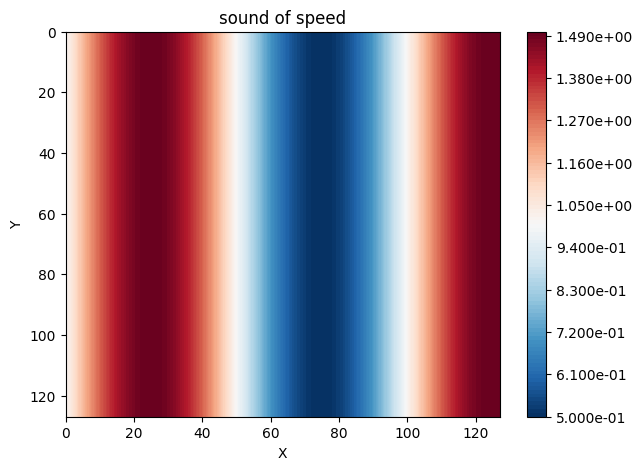

In [36]:
sos = model.sos
plot2Dimage(x_end=sos.size(0),
            y_end=sos.size(1),
            f=sos,
            title='sound of speed')

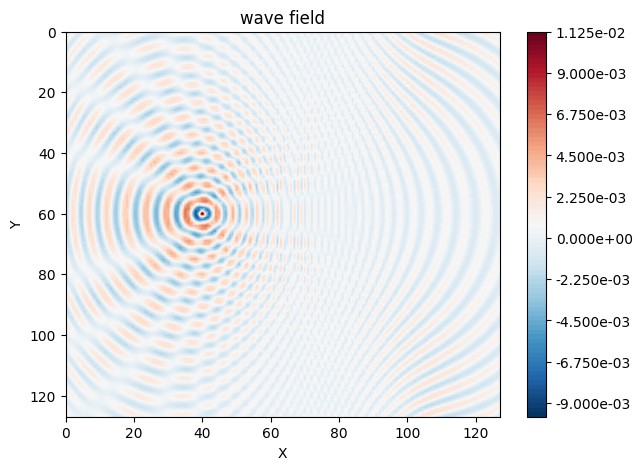

In [37]:
u_real = torch.real(u.detach().cpu())
plot2Dimage(x_end=u_real.size(0),
            y_end=u_real.size(1),
            f=u_real,
            title='wave field')